## 1.Make classification data and get it ready

In [2]:
import sklearn
from sklearn.datasets import make_circles
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
#Create circles
X,y = make_circles(n_samples=1000, noise=0.3, random_state=42)
X.shape, y.shape

((1000, 2), (1000,))

In [22]:
print(f"First 5 samples of X:\n {X[:5]},\nFirst 5 samples of y:\n  {y[:5]}")

First 5 samples of X:
 [[ 0.59171471  0.43674853]
 [-0.45745002  0.36160118]
 [-1.01069349  0.83042101]
 [-0.87169639  0.41407292]
 [ 0.48803455 -0.87258708]],
First 5 samples of y:
  [1 1 1 1 0]


In [23]:
circles = pd.DataFrame({"X1":X[:,0],
                      "X2": X[:,1],
                      "label": y})
circles.head(10)

,X1,X2,label
0,0.591715,0.436749,1
1,-0.457450,0.361601,1
2,-1.010693,0.830421,1
3,-0.871696,0.414073,1
4,0.488035,-0.872587,0
5,-0.347874,1.103071,1
6,-0.046008,0.834056,1
7,0.610994,0.306608,1
8,-0.255312,-0.879601,1
9,0.025255,1.300938,0


In [24]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

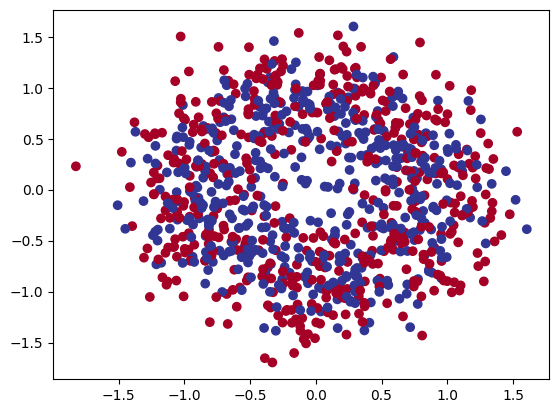

In [25]:
#visualize
plt.scatter(x=X[:,0],
           y=X[:,1],
           c=y,
           cmap=plt.cm.RdYlBu);

In [27]:
import torch
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

In [29]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
type(X), X.dtype

(torch.Tensor, torch.float32)

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.8, random_state=42)
len(X_train)

800

## 2. Building a model

Let's build a model to classify our blue and red dots.

To do so, we want to:

1. Setup device agonistic code so our code will run on an accelerator (GPU) if there is one     
2. Construct a model (by subclassing nn.Module)     
3. Define a loss function and optimizer      
4. Create a training and test loop      

let's create a model that:

1. Subclasses nn.Module (almost all models in PyTorch subclass nn.Module)         
2. Create 2 nn.Linear() layers that are capable of handling the shapes of our data          
3. Defines a forward() method that outlines the forward pass (or forward computation) of the model         
4. Instatiate an instance of our model class and send it to the target device        

In [40]:
from torch import nn

# 1. Construct a model that subclasses nn.Module
class CircleModelV0():
    def __init__(self):
        super().__init__()

         # 2. Create 2 nn.Linear layers capable of handling the shapes of our data
        self.layer_1 = nn.Linear(in_features=2, out_features=5)   # takes in 2 features and upscales to 5 features 
        self.layer_2 = nn.Linear(in_features=5, out_features=1)   # takes in 5 features from previous layer and outputs a single feature (same shape as y)

    # 3. Define a forward() method that outlines the forward pass
    def forward(self, x):
        return self.layer_2(self.layer_1(x))     # x -> layer_1 ->  layer_2 -> output

# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV0()
model_0

In [42]:
model_0 =nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
)
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.1452,  0.2796],
                      [-0.3995,  0.1198],
                      [ 0.6488, -0.0354],
                      [ 0.1386,  0.1755],
                      [-0.4113,  0.6707]])),
             ('0.bias', tensor([ 0.1398,  0.2251, -0.5335,  0.4949, -0.0212])),
             ('1.weight',
              tensor([[ 0.0232,  0.3662, -0.2865,  0.1219,  0.2007]])),
             ('1.bias', tensor([0.3017]))])

Init signature: nn.Sequential(*args)
Docstring:     
A sequential container.

Modules will be added to it in the order they are passed in the
constructor. Alternatively, an ``OrderedDict`` of modules can be
passed in. The ``forward()`` method of ``Sequential`` accepts any
input and forwards it to the first module it contains. It then
"chains" outputs to inputs sequentially for each subsequent module,
finally returning the output of the last module.

The value a ``Sequential`` provides over manually calling a sequence
of modules is that it allows treating the whole container as a
single module, such that performing a transformation on the
``Sequential`` applies to each of the modules it stores (which are
each a registered submodule of the ``Sequential``).

What's the difference between a ``Sequential`` and a
:class:`torch.nn.ModuleList`? A ``ModuleList`` is exactly what it
sounds like--a list for storing ``Module`` s! On the other hand,
the layers in a ``Sequential`` are connected in a 